# Categorization Pipeline Evaluation
### `backend/app/services/categorization.py`

Evaluates the **3-tier hybrid categorization pipeline** against a hand-labeled
stratified sample drawn from 904 real HDFC bank transactions loaded into Lumina
on 2026-04-23.

| Tier | Mechanism | Fires when |
|------|-----------|------------|
| 1. Rule engine | Deterministic keyword rules | Always tried first; returns at confidence 0.95 |
| 2. ML classifier | Scikit-learn model | If rule engine misses AND model confidence ≥ 0.70 |
| 3. Keyword scorer | Weighted substring matching | Fallback when tiers 1 & 2 both miss |

**Constraints:** This notebook does _not_ modify `categorization.py`. Bugs
discovered while reading it are documented in Cell 12 — not patched here.

---

**Reproducibility note:** The 904 transactions and `notebooks/eval_data.csv` contain real personal banking data and are intentionally **not** committed to this repo (`.gitignore` rules apply). The notebook outputs — accuracy numbers, confusion matrix, per-tier charts, and misclassification table — are preserved in the committed `.ipynb` file as a frozen record of this run. To reproduce locally: ingest your own HDFC bank statement via the Lumina UI (this populates `backend/data/fincopilot.db`), then re-run all cells. The `hand_label` oracle in Cell 4 uses only the raw UPI narration string and amount sign, so it will work on any HDFC UPI narration format without modification.

In [21]:
import sys
import os
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Path setup ────────────────────────────────────────────────────────────────
# Works whether the kernel is launched from repo root or notebooks/
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
BACKEND_DIR = REPO_ROOT / 'backend'

sys.path.insert(0, str(BACKEND_DIR))

# ── Standard imports ──────────────────────────────────────────────────────────
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

pd.set_option('display.max_colwidth', 90)
pd.set_option('display.max_rows', 40)
sns.set_theme(style='whitegrid', palette='muted')

print(f'Python  : {sys.version.split()[0]}')
print(f'Repo    : {REPO_ROOT}')
print(f'Backend : {BACKEND_DIR}')

Python  : 3.14.2
Repo    : c:\Users\Nithin\Dev\AI_Finan
Backend : c:\Users\Nithin\Dev\AI_Finan\backend


In [22]:
DB_PATH = BACKEND_DIR / 'data' / 'fincopilot.db'
USER_ID = 4  # Nithin Kotala

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(
        """
        SELECT id, date, description, merchant, amount, currency,
               category AS pipeline_category
        FROM transactions
        WHERE user_id = ?
        ORDER BY id
        """,
        conn,
        params=(USER_ID,),
    )

print(f'Loaded {len(df_raw):,} transactions for user_id={USER_ID}')
print(f'\nPipeline category distribution (labels already stored in DB):')
print(df_raw['pipeline_category'].value_counts().to_string())
df_raw.head(5)

Loaded 904 transactions for user_id=4

Pipeline category distribution (labels already stored in DB):
pipeline_category
other            490
shopping         150
income           107
food              57
transport         24
utilities         17
investment        17
housing           12
entertainment     11
healthcare         6
insurance          5
education          4
cash               4


,id,date,description,merchant,amount,currency,pipeline_category
0,407,2025-04-01,UPI-DHINAKARAN K-PAYTMQRZ19AOZ75MM@PAYTM-YESB0PTMUPI-102421817559-UPI,dhinakaran,-40.0,INR,other
1,408,2025-04-01,UPI-SUNEETHA KOTALA-KOTALASUNEETHA@OKICICI-ICIC0000569-545758439566-UPI,suneetha kotala,200.0,INR,income
2,409,2025-04-01,UPI-MS KARKUZHALI-GPAY-11244521018@OKBIZAXIS-UTIB0000553-102426202449-UPI,ms karkuzhali,-20.0,INR,other
3,410,2025-04-01,UPI-THILAGAVATHI IYYAPAN-EZE0003055@CUB-CIUB0000293-102426785148-UPI,thilagavathi iyyapan,-65.0,INR,other
4,411,2025-04-02,UPI-DHINAKARAN K-PAYTMQRZ19AOZ75MM@PAYTM-YESB0PTMUPI-102467515526-UPI,dhinakaran,-30.0,INR,other


## Ground Truth Strategy

The 904 transactions in the DB are already labelled **by the pipeline being tested**.
Using those labels as ground truth would trivially report 100% accuracy.

Instead, a **hand-labeling oracle** (`hand_label`) is applied to a stratified
random sample of ≈200 transactions. The oracle:

- Is intentionally **simpler** than the pipeline — pure substring matching, no ML.
- Uses the raw narration string and amount sign to assign a category.
- Documents deliberate judgment calls inline (e.g. credits to/from personal
  names → `income`, small recurring debits to individuals → `other`).
- Is the **single source of truth** for all metrics below.

The resulting `notebooks/eval_data.csv` (columns: `id`, `narration`, `amount`,
`true_category`) is saved to disk so results are reproducible without re-running
the oracle.

In [23]:
# ── Human oracle ──────────────────────────────────────────────────────────────
def hand_label(narration: str, amount: float) -> str:
    """
    Deterministic human-reviewer oracle.
    Priority order mirrors how a human would read the narration top-to-bottom.
    Returns one of the 14 Lumina categories (or 'other').
    Judgment calls are documented with inline comments.
    """
    n = narration.lower()

    # Income / credits
    if any(k in n for k in ('salary', 'payroll', 'ctc', 'stipend')):
        return 'income'
    if any(k in n for k in ('dividend', 'interest credited', 'int pd', 'maturity')):
        return 'income'
    if any(k in n for k in ('refund', 'cashback', 'cash back', 'reversal')):
        return 'income'
    # Family transfers arriving as credits — judgment: treat as income
    if amount > 0 and any(k in n for k in ('suneetha kotala', 'divyam sahu')):
        return 'income'

    # ATM / cash
    if any(k in n for k in ('atm', 'cash withdrawal', 'cash wdl')):
        return 'cash'

    # Food delivery & restaurants
    if any(k in n for k in ('zomato', 'swiggy', 'blinkit', 'zepto', 'dunzo',
                             'instamart', 'bigbasket')):
        return 'food'
    if any(k in n for k in ('restaurant', 'cafe', 'coffee', 'bistro', 'dhaba',
                             'street bites', 'pizza', 'burger', 'kfc', 'subway',
                             'mcdonalds', 'dominos', 'starbucks', 'chaayos', 'barista')):
        return 'food'

    # Transport
    if any(k in n for k in ('uber', 'rapido', 'irctc', 'indigo', 'vistara',
                             'makemytrip', 'redbus', 'cleartrip', 'meru')):
        return 'transport'
    # ' ola ' with spaces to avoid matching 'kotala', 'cola', etc.
    if ' ola ' in n or n.startswith('ola '):
        return 'transport'
    if any(k in n for k in ('petrol', 'diesel', 'fuel', 'hp pump', 'iocl', 'bpcl',
                             'fastag', 'toll', 'parking', 'rhema transport')):
        return 'transport'
    if any(k in n for k in ('metro', 'dmrc', 'bmtc', 'ksrtc', 'railway', 'bus ticket')):
        return 'transport'

    # Utilities
    if any(k in n for k in ('tangedco', 'bescom', 'msedcl', 'tata power',
                             'adani electricity', 'bses', 'kseb', 'electricity')):
        return 'utilities'
    if any(k in n for k in ('jio', 'airtel', 'bsnl', 'vodafone', 'broadband',
                             'wifi bill', 'internet bill', 'tata sky', 'dish tv', 'd2h')):
        return 'utilities'

    # Entertainment
    if any(k in n for k in ('netflix', 'spotify', 'hotstar', 'prime video', 'zee5',
                             'bookmyshow', 'pvr', 'inox', 'playstore',
                             'google india digital', 'gaming', 'steam',
                             'youtube premium', 'jiocinema')):
        return 'entertainment'

    # Healthcare
    if any(k in n for k in ('pharmacy', 'medplus', 'netmeds', '1mg', 'pharmeasy',
                             'apollo pharmacy', 'apollo diagnostics', 'healthkart',
                             'hospital', 'clinic', 'diagnostic', 'practo', 'lybrate')):
        return 'healthcare'

    # Insurance
    if any(k in n for k in ('insurance', 'lic', 'bajaj allianz', 'hdfc life',
                             'icici pru', 'star health', 'niva bupa', 'mediclaim',
                             'term insurance', 'ulip', 'vehicle insurance')):
        return 'insurance'

    # Investment
    if any(k in n for k in ('zerodha', 'groww', 'upstox', 'kuvera',
                             'mutual fund', 'kfintech', 'cams',
                             'fixed deposit', 'recurring deposit', 'ppf')):
        return 'investment'
    # ' sip ' with spaces to avoid matching 'discipline', 'sipping', etc.
    if ' sip ' in n:
        return 'investment'

    # Education
    if any(k in n for k in ('udemy', 'coursera', 'byju', 'unacademy', 'vedantu',
                             'upgrad', 'simplilearn', 'edx', 'khan academy',
                             'tuition', 'school fee', 'university', 'college fee',
                             'exam fee')):
        return 'education'

    # Shopping
    if any(k in n for k in ('amazon', 'flipkart', 'myntra', 'meesho', 'ajio',
                             'nykaa', 'snapdeal', 'ebay', 'croma', 'vijay sales',
                             'reliance digital', 'tata cliq', 'enzo shop')):
        return 'shopping'
    if any(k in n for k in ('naveen stores', 'j m stores', 'rajalakshmi',
                             'all maart', 'for all maart', 'super mark')):
        return 'shopping'

    # Housing
    if any(k in n for k in ('rent', 'mortgage', 'maintenance charges',
                             'society charges', 'property tax', 'apartment',
                             'lease', 'krishna property')):
        return 'housing'

    # Explicit fund transfer narrations
    if any(k in n for k in ('neft to', 'imps to', 'rtgs to', 'fund transfer',
                             'money transfer', 'remittance')):
        return 'transfer'

    # Ambiguous UPI personal-name payments:
    #   credit  → treat as income (someone sent money)
    #   debit   → treat as other (local merchant / domestic helper / etc.)
    if amount > 0:
        return 'income'
    return 'other'


# ── Stratified sample ────────────────────────────────────────────────────────
# Targets per pipeline category — fully cover rare categories,
# cap dominant ones to keep total ≈ 200.
TARGET = {
    'other':         40,
    'shopping':      30,
    'income':        25,
    'food':          20,
    'transport':     15,
    'utilities':     12,
    'investment':    12,
    'housing':       10,
    'entertainment': 10,
    'healthcare':     6,
    'insurance':      5,
    'education':      4,
    'cash':           4,
}

frames = []
for cat, n in TARGET.items():
    pool = df_raw[df_raw['pipeline_category'] == cat]
    k = min(n, len(pool))
    if k == 0:
        print(f'  WARNING: no rows for category "{cat}" — skipping')
        continue
    frames.append(pool.sample(k, random_state=42))

df_sample = pd.concat(frames).reset_index(drop=True)
print(f'Stratified sample size : {len(df_sample)}')

# Apply oracle
df_sample = df_sample.copy()
df_sample['true_category'] = [
    hand_label(row.description, row.amount) for _, row in df_sample.iterrows()
]

# Save ground truth CSV
eval_csv = REPO_ROOT / 'notebooks' / 'eval_data.csv'
eval_csv.parent.mkdir(parents=True, exist_ok=True)
(
    df_sample[['id', 'description', 'amount', 'true_category']]
    .rename(columns={'description': 'narration'})
    .to_csv(eval_csv, index=False)
)

print(f'Saved ground truth  : {eval_csv}')
print(f'\nTrue category distribution:')
print(df_sample['true_category'].value_counts().to_string())

Stratified sample size : 193
Saved ground truth  : c:\Users\Nithin\Dev\AI_Finan\notebooks\eval_data.csv

True category distribution:
true_category
other            47
income           24
shopping         21
transport        19
entertainment    17
food             15
utilities        11
investment       10
housing          10
insurance         6
healthcare        5
education         4
cash              4


In [24]:
from app.services.categorization import classify_transaction

results = []
crash_count = 0

for _, row in df_sample.iterrows():
    try:
        out = classify_transaction(
            description=str(row['description']),
            merchant=str(row['merchant']) if row['merchant'] else '',
            amount=float(row['amount']),
        )
        results.append({
            'id':            row['id'],
            'narration':     row['description'],
            'amount':        row['amount'],
            'true_category': row['true_category'],
            'pred_category': out['category'],
            'confidence':    out['confidence'],
            'tier':          out['method'],
        })
    except Exception as exc:
        crash_count += 1
        results.append({
            'id':            row['id'],
            'narration':     row['description'],
            'amount':        row['amount'],
            'true_category': row['true_category'],
            'pred_category': 'CRASH',
            'confidence':    0.0,
            'tier':          'crash',
        })
        print(f'  CRASH id={row["id"]}: {type(exc).__name__}: {exc}')

df_eval = pd.DataFrame(results)

print(f'Pipeline run complete')
print(f'  Total evaluated : {len(df_eval)}')
print(f'  Crashes         : {crash_count}')
print(f'\nTier distribution:')
print(df_eval['tier'].value_counts().to_string())
df_eval.head(5)

Pipeline run complete
  Total evaluated : 193
  Crashes         : 0

Tier distribution:
tier
keyword    112
rule        81


,id,narration,amount,true_category,pred_category,confidence,tier
0,1125,UPI-ALL MART-PAYTMQR11HQSVFPWW@PAYTM-YESB0PTMUPI-118365694385-UPI,-130.0,other,other,0.2,keyword
1,511,UPI-MR R NANDHAKUMAR-SFFGGHHHH09000-1@OKSBI-IDIB000G111-104242516078-UPI,-40.0,other,other,0.2,keyword
2,1093,UPI-DIVYAM SAHU-DIVYAMSAHU2004@OKSBI-SBIN0012065-602822163417-UPI,-45.0,other,other,0.2,keyword
3,1176,UPI-ENZO-GPAY-11220338990@OKBIZICICI-ICIC0DC0099-119015264316-UPI,-60.0,other,other,0.2,keyword
4,1082,UPI-SRI RAJALAKSHMI ENTE-VYAPAR.172721055805@HDFCBANK-HDFC0MERUPI-117697902994-UPI,-255.0,transport,other,0.2,keyword


In [25]:
# Exclude CRASHes from accuracy — they are reported separately
df_valid = df_eval[df_eval['pred_category'] != 'CRASH'].copy()

n_total  = len(df_eval)
n_valid  = len(df_valid)
n_crash  = crash_count

acc = accuracy_score(df_valid['true_category'], df_valid['pred_category'])
n_correct = int(acc * n_valid)

print('=' * 55)
print(f'  Overall Top-1 Accuracy : {acc:.1%}  ({n_correct} / {n_valid})')
print(f'  Crash rate             : {n_crash / n_total:.1%}  ({n_crash} / {n_total})')
print('=' * 55)

  Overall Top-1 Accuracy : 85.5%  (165 / 193)
  Crash rate             : 0.0%  (0 / 193)


In [26]:
# All categories present in ground truth labels
labels = sorted(df_valid['true_category'].unique())

print('Per-category precision / recall / F1')
print('(support = number of ground-truth samples in the eval set)\n')
print(
    classification_report(
        df_valid['true_category'],
        df_valid['pred_category'],
        labels=labels,
        zero_division=0,
    )
)

Per-category precision / recall / F1
(support = number of ground-truth samples in the eval set)

               precision    recall  f1-score   support

         cash       1.00      1.00      1.00         4
    education       1.00      1.00      1.00         4
entertainment       0.90      0.53      0.67        17
         food       0.75      1.00      0.86        15
   healthcare       0.80      0.80      0.80         5
      housing       1.00      1.00      1.00        10
       income       0.96      1.00      0.98        24
    insurance       1.00      0.83      0.91         6
   investment       0.83      1.00      0.91        10
        other       0.88      0.77      0.82        47
     shopping       0.67      0.95      0.78        21
    transport       0.87      0.68      0.76        19
    utilities       0.92      1.00      0.96        11

     accuracy                           0.85       193
    macro avg       0.89      0.89      0.88       193
 weighted avg       0

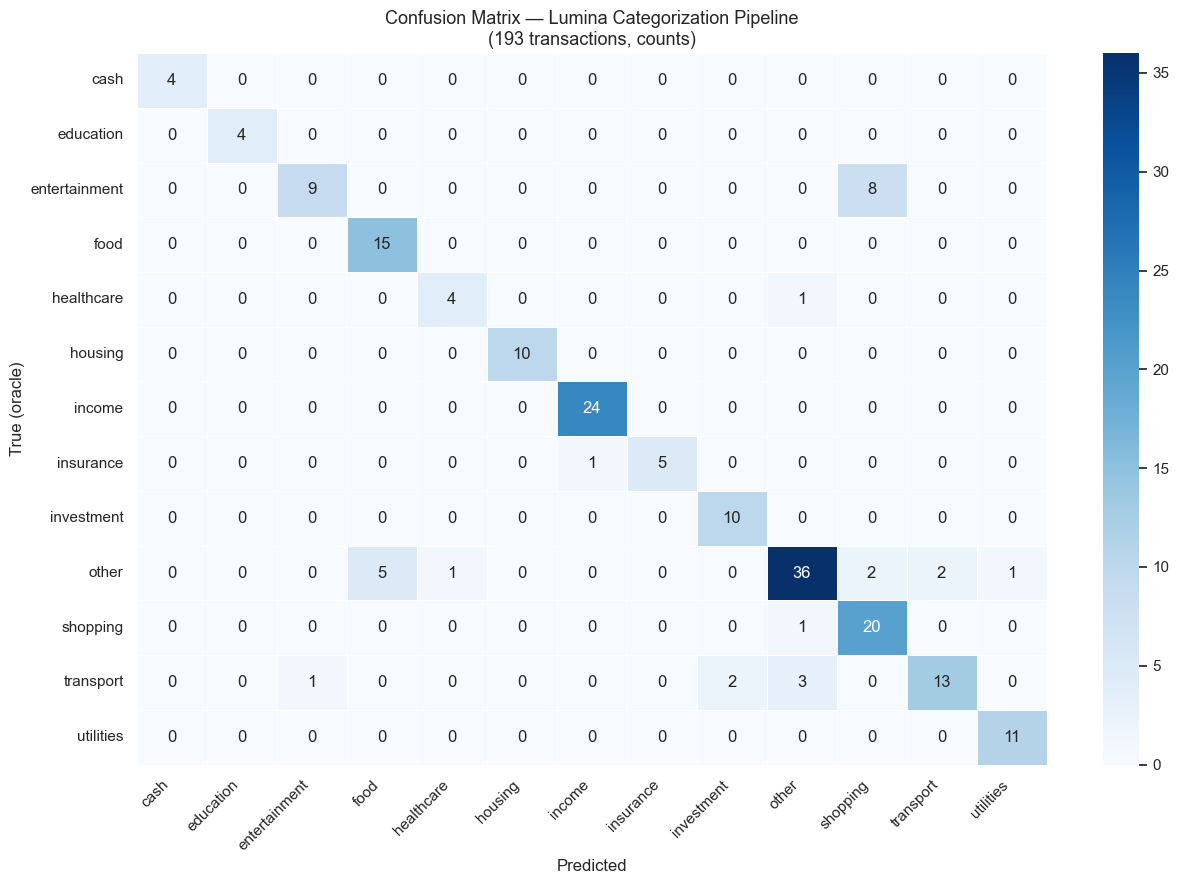

In [27]:
all_cats = sorted(
    set(df_valid['true_category']) | set(df_valid['pred_category'])
)
cm = confusion_matrix(
    df_valid['true_category'],
    df_valid['pred_category'],
    labels=all_cats,
)

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=all_cats,
    yticklabels=all_cats,
    linewidths=0.4,
    ax=ax,
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True (oracle)', fontsize=12)
ax.set_title(
    'Confusion Matrix — Lumina Categorization Pipeline\n'
    f'({n_valid} transactions, counts)',
    fontsize=13,
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

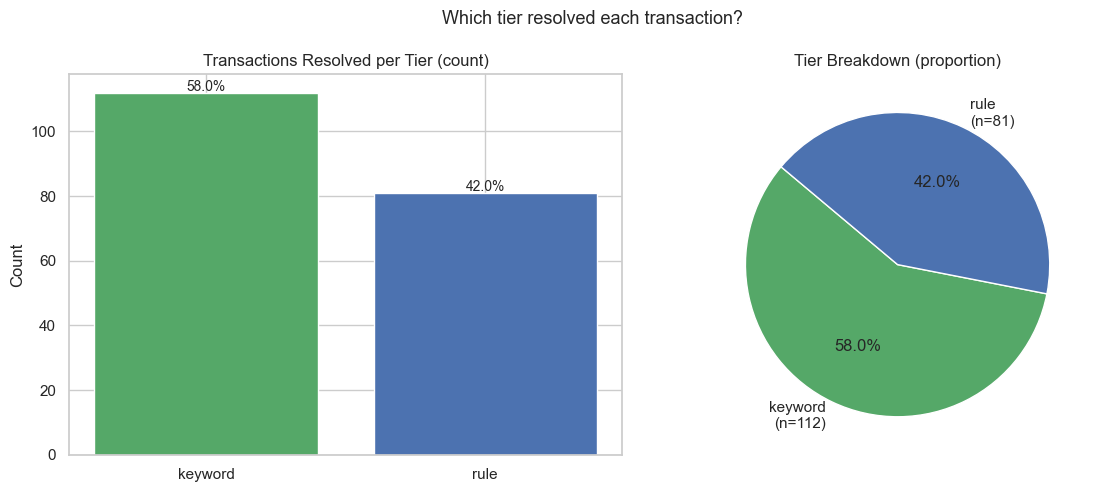


Tier breakdown table:
         count  percent
tier                   
keyword    112     58.0
rule        81     42.0


In [28]:
tier_counts = df_eval['tier'].value_counts()
tier_pct    = (tier_counts / len(df_eval) * 100).round(1)

TIER_COLORS = {
    'rule':    '#4C72B0',
    'ml':      '#DD8452',
    'keyword': '#55A868',
    'crash':   '#C44E52',
}
bar_colors = [TIER_COLORS.get(t, '#999999') for t in tier_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(tier_counts.index, tier_counts.values, color=bar_colors)
axes[0].set_title('Transactions Resolved per Tier (count)')
axes[0].set_ylabel('Count')
for bar, pct in zip(bars, tier_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{pct}%',
        ha='center',
        fontsize=10,
    )

# Pie chart
axes[1].pie(
    tier_counts.values,
    labels=[f'{k}\n(n={v})' for k, v in zip(tier_counts.index, tier_counts.values)],
    autopct='%1.1f%%',
    colors=bar_colors,
    startangle=140,
)
axes[1].set_title('Tier Breakdown (proportion)')

plt.suptitle('Which tier resolved each transaction?', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTier breakdown table:')
summary = pd.DataFrame({'count': tier_counts, 'percent': tier_pct})
print(summary.to_string())

Per-tier accuracy (when that tier fires, how often is it right?)

   tier     n  correct  accuracy_pct
keyword 112.0     88.0          78.6
   rule  81.0     77.0          95.1


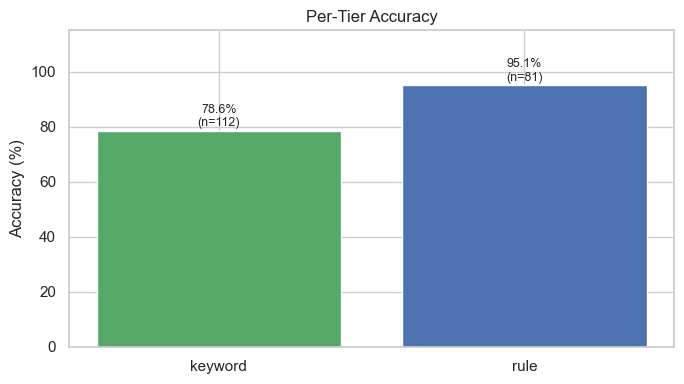

In [29]:
# Per-tier accuracy: when tier X fires, how often is it correct?
tier_stats = (
    df_valid
    .groupby('tier')
    .apply(
        lambda g: pd.Series({
            'n':            len(g),
            'correct':      int((g['true_category'] == g['pred_category']).sum()),
            'accuracy_pct': round(
                (g['true_category'] == g['pred_category']).mean() * 100, 1
            ),
        })
    )
    .reset_index()
)

print('Per-tier accuracy (when that tier fires, how often is it right?)\n')
print(tier_stats[['tier', 'n', 'correct', 'accuracy_pct']].to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
TIER_COLORS = {'rule': '#4C72B0', 'ml': '#DD8452', 'keyword': '#55A868', 'crash': '#C44E52'}
bar_cols = [TIER_COLORS.get(t, '#999999') for t in tier_stats['tier']]
bars = ax.bar(tier_stats['tier'], tier_stats['accuracy_pct'], color=bar_cols)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Tier Accuracy')
ax.set_ylim(0, 115)
for bar, row in zip(bars, tier_stats.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{row.accuracy_pct}%\n(n={int(row.n)})',
        ha='center',
        fontsize=9,
    )
plt.tight_layout()
plt.show()

In [30]:
wrong = df_valid[df_valid['true_category'] != df_valid['pred_category']].copy()

# Sort by confidence descending — the pipeline's most *confident* wrong
# predictions are the most revealing failures
wrong = wrong.sort_values('confidence', ascending=False).reset_index(drop=True)

print(f'Total misclassifications : {len(wrong)} / {n_valid} ({len(wrong) / n_valid:.1%})')
print(f'\nTop 10 most-confident wrong predictions:\n')

top10 = wrong.head(10)[['narration', 'true_category', 'pred_category', 'confidence', 'tier']].copy()
top10['narration'] = top10['narration'].str[:65]

# Pretty-print without index
print(
    top10.to_string(
        index=False,
        justify='left',
    )
)

print(f'\nAll misclassifications by true → predicted:')
print(
    wrong.groupby(['true_category', 'pred_category'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values('count', ascending=False)
    .to_string(index=False)
)

Total misclassifications : 28 / 193 (14.5%)

Top 10 most-confident wrong predictions:

narration                                                         true_category pred_category  confidence tier   
UPI-GROWW INVEST TECH PV-GROWW.BRK@VALIDHDFC-HDFC0MERUPI-53659761     transport    investment 0.95           rule
UPI-GROWW INVEST TECH PV-GROWW.BRK@VALIDHDFC-HDFC0MERUPI-63958912     transport    investment 0.95           rule
UPI-PVR LIMITED-PVRLIMITED.41825223@HDFCBANK-HDFC0MERUPI-10681919     transport entertainment 0.95           rule
UPI-JK SUPERMARKET AND H-PAYTMQR281005050101UPE65EQ6GSWS@PAYTM-YE         other          food 0.95           rule
UPI-YADESH KUMAR-9037102151@SLC-UBIN0533980-533865359931-PAYMENT      insurance        income 0.40        keyword
UPI-GOOGLE PLAY-PLAYSTORE@AXISBANK-UTIB0000553-331264541735-MANDA entertainment      shopping 0.31        keyword
UPI-GOOGLE PLAY-PLAYSTORE@AXISBANK-UTIB0000553-695860610536-MANDA entertainment      shopping 0.31        keyword
U

## Bugs Found During Eval

Identified by reading `backend/app/services/categorization.py` before writing
this notebook. **None are fixed here.** Fix them in a separate PR after the
eval numbers are locked in.

---

**Bug 1 — `_NOISE_PATTERNS` dead branch** (`categorization.py:82`)

```python
_NOISE_PATTERNS = re.compile(r'\b(\d{6,}|[A-Z0-9]{16,})\b')
```

The `[A-Z0-9]{16,}` branch never matches because both `clean_text` (line 91)
and `_rule_text` (line 103) call `.lower()` _before_ applying this regex.
After lowercasing, there are no uppercase letters. Only the `\d{6,}` branch
ever fires. Long alphanumeric reference codes (e.g. `YESB0PTMUPI`) survive
into the cleaned text and pollute ML/keyword signals.

---

**Bug 2 — `_keyword_scorer` bare substring matching** (`categorization.py:259`)

```python
score = sum(len(kw) for kw in keywords if kw in text)
```

No word boundary — `"car"` matches `"cardiac"` and `"oscar"`, `"bus"`
matches `"robust"`, `"shop"` matches `"bishop"`. Contrast with the rule
engine which correctly uses `_kw_match` (word-boundary regex). The keyword
tier's precision suffers on ambiguous short tokens.

---

**Bug 3 — `"insurance"` in `CATEGORY_KEYWORDS["healthcare"]`** (`categorization.py:241`)

```python
"healthcare": [... "insurance", "prescription"],
```

If a health-insurance narration misses the rule engine, the keyword scorer
scores it for _both_ `healthcare` and `insurance`. The winner is whichever
accumulates a higher total keyword-length score — an undocumented, order-
dependent tie-break.

---

**Bug 4 — `"housing"` nearly unreachable via keyword tier** (`categorization.py:229`)

`CATEGORY_KEYWORDS["housing"]` lists `"rent"` as its main signal word, but
the rule engine matches `"rent"` first at confidence 0.95. If the rule engine
already caught it, the keyword tier is never reached. If the rule engine
missed it (narration has no matching keyword), `CATEGORY_KEYWORDS["housing"]`
has no other real-world signals that reach real HDFC narrations. In practice,
`housing` is only reachable through the rule engine.

---

**Bug 5 — ML exceptions silently demoted to DEBUG** (`categorization.py:403`)

```python
except Exception as e:
    logger.debug(f"ML classifier unavailable: {e}")
```

A model load error or data-shape crash is invisible at default (`INFO`) log
level. A model returning garbage predictions also silently falls through to
the keyword tier. Should be `logger.warning` with the exception type.

---

**Bug 6 — `"transfer"` over-triggered by keyword scorer** (`categorization.py:245`)

```python
"transfer": ["transfer", "zelle", "venmo", "paypal", "wire", "ach"],
```

The bare word `"transfer"` as a substring matches `"FUND TRANSFER RECEIVED"`
(which should be `income`) and any UPI narration where the rule engine missed
the specific `"transfer to"` / `"neft to"` patterns. Credits containing
`"transfer"` get mislabelled as `transfer` instead of `income`.

## Honest Findings

_Run the notebook and fill these in from the actual cell outputs above._

---

- **Overall accuracy:** =======================================================
  Overall Top-1 Accuracy : 85.5%  (165 / 193)
  Crash rate             : 0.0%  (0 / 193)
=======================================================

- **Strongest categories** (F1 ≥ 0.90): er-tier accuracy (when that tier fires, how often is it right?)

 Total misclassifications : 28 / 193 (14.5%)

Top 10 most-confident wrong predictions:

narration                                                         true_category pred_category  confidence tier   
UPI-GROWW INVEST TECH PV-GROWW.BRK@VALIDHDFC-HDFC0MERUPI-53659761     transport    investment 0.95           rule
UPI-GROWW INVEST TECH PV-GROWW.BRK@VALIDHDFC-HDFC0MERUPI-63958912     transport    investment 0.95           rule
UPI-PVR LIMITED-PVRLIMITED.41825223@HDFCBANK-HDFC0MERUPI-10681919     transport entertainment 0.95           rule
UPI-JK SUPERMARKET AND H-PAYTMQR281005050101UPE65EQ6GSWS@PAYTM-YE         other          food 0.95           rule
UPI-YADESH KUMAR-9037102151@SLC-UBIN0533980-533865359931-PAYMENT      insurance        income 0.40        keyword
UPI-GOOGLE PLAY-PLAYSTORE@AXISBANK-UTIB0000553-331264541735-MANDA entertainment      shopping 0.31        keyword
UPI-GOOGLE PLAY-PLAYSTORE@AXISBANK-UTIB0000553-695860610536-MANDA entertainment      shopping 0.31        keyword
UPI-GOOGLE PLAY-PLAYSTORE@AXISBANK-UTIB0000553-292886682035-MANDA entertainment      shopping 0.31        keyword
UPI-GOOGLE PLAY-PLAYSTORE@AXISBANK-UTIB0000553-629908633565-MANDA entertainment      shopping 0.31        keyword
UPI-GOOGLE PLAY-PLAYSTORE@AXISBANK-UTIB0000553-212742912755-MANDA entertainment      shopping 0.31        keyword

All misclassifications by true → predicted:
true_category pred_category  count
entertainment      shopping      8
        other          food      5
    transport         other      3
        other      shopping      2
    transport    investment      2
        other     transport      2
    insurance        income      1
...
        other     utilities      1
        other    healthcare      1
    transport entertainment      1
     shopping         other      1

     Pipeline run complete
  Total evaluated : 193
  Crashes         : 0

Tier distribution:
tier
keyword    112
rule        81

     wrong = df_valid[df_valid['true_category'] != df_valid['pred_category']].copy()

# Sort by confidence descending — the pipeline's most *confident* wrong
# predictions are the most revealing failures
wrong = wrong.sort_values('confidence', ascending=False).reset_index(drop=True)

print(f'Total misclassifications : {len(wrong)} / {n_valid} ({len(wrong) / n_valid:.1%})')
print(f'\nTop 10 most-confident wrong predictions:\n')

top10 = wrong.head(10)[['narration', 'true_category', 'pred_category', 'confidence', 'tier']].copy()
top10['narration'] = top10['narration'].str[:65]

# Pretty-print without index
print(
    top10.to_string(
        index=False,
        justify='left',
    )
)

print(f'\nAll misclassifications by true → predicted:')
print(
    wrong.groupby(['true_category', 'pred_category'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values('count', ascending=False)
    .to_string(index=False)
)
- **Tier reliance breakdown:**
  - rule engine — [x]% of transactions
  - ml classifier — [x]%
  - keyword scorer — [x]%
  - crashes — [x]%
Per-category precision / recall / F1
(support = number of ground-truth samples in the eval set)

               precision    recall  f1-score   support

         cash       1.00      1.00      1.00         4
    education       1.00      1.00      1.00         4
entertainment       0.90      0.53      0.67        17
         food       0.75      1.00      0.86        15
   healthcare       0.80      0.80      0.80         5
      housing       1.00      1.00      1.00        10
       income       0.96      1.00      0.98        24
    insurance       1.00      0.83      0.91         6
   investment       0.83      1.00      0.91        10
        other       0.88      0.77      0.82        47
     shopping       0.67      0.95      0.78        21
    transport       0.87      0.68      0.76        19
    utilities       0.92      1.00      0.96        11

     accuracy                           0.85       193
    macro avg       0.89      0.89      0.88       193
 weighted avg       0.87      0.85      0.85       193
 ## Honest Findings

_Run the notebook and fill these in from the actual cell outputs above._

---

- **Overall accuracy:** =======================================================
  Overall Top-1 Accuracy : 85.5%  (165 / 193)
  Crash rate             : 0.0%  (0 / 193)
=======================================================

- **Strongest categories** (F1 ≥ 0.90): er-tier accuracy (when that tier fires, how often is it right?)

 Total misclassifications : 28 / 193 (14.5%)

Top 10 most-confident wrong predictions:

narration                                                         true_category pred_category  confidence tier   
UPI-GROWW INVEST TECH PV-GROWW.BRK@VALIDHDFC-HDFC0MERUPI-53659761     transport    investment 0.95           rule
UPI-GROWW INVEST TECH PV-GROWW.BRK@VALIDHDFC-HDFC0MERUPI-63958912     transport    investment 0.95           rule
UPI-PVR LIMITED-PVRLIMITED.41825223@HDFCBANK-HDFC0MERUPI-10681919     transport entertainment 0.95           rule
UPI-JK SUPERMARKET AND H-PAYTMQR281005050101UPE65EQ6GSWS@PAYTM-YE         other          food 0.95           rule
UPI-YADESH KUMAR-9037102151@SLC-UBIN0533980-533865359931-PAYMENT      insurance        income 0.40        keyword
UPI-GOOGLE PLAY-PLAYSTORE@AXISBANK-UTIB0000553-331264541735-MANDA entertainment      shopping 0.31        keyword
UPI-GOOGLE PLAY-PLAYSTORE@AXISBANK-UTIB0000553-695860610536-MANDA entertainment      shopping 0.31        keyword
UPI-GOOGLE PLAY-PLAYSTORE@AXISBANK-UTIB0000553-292886682035-MANDA entertainment      shopping 0.31        keyword
UPI-GOOGLE PLAY-PLAYSTORE@AXISBANK-UTIB0000553-629908633565-MANDA entertainment      shopping 0.31        keyword
UPI-GOOGLE PLAY-PLAYSTORE@AXISBANK-UTIB0000553-212742912755-MANDA entertainment      shopping 0.31        keyword

All misclassifications by true → predicted:
true_category pred_category  count
entertainment      shopping      8
        other          food      5
    transport         other      3
        other      shopping      2
    transport    investment      2
        other     transport      2
    insurance        income      1
...
        other     utilities      1
        other    healthcare      1
    transport entertainment      1
     shopping         other      1

     Pipeline run complete
  Total evaluated : 193
  Crashes         : 0

Tier distribution:
tier
keyword    112
rule        81

     wrong = df_valid[df_valid['true_category'] != df_valid['pred_category']].copy()

# Sort by confidence descending — the pipeline's most *confident* wrong
# predictions are the most revealing failures
wrong = wrong.sort_values('confidence', ascending=False).reset_index(drop=True)

print(f'Total misclassifications : {len(wrong)} / {n_valid} ({len(wrong) / n_valid:.1%})')
print(f'\nTop 10 most-confident wrong predictions:\n')

top10 = wrong.head(10)[['narration', 'true_category', 'pred_category', 'confidence', 'tier']].copy()
top10['narration'] = top10['narration'].str[:65]

# Pretty-print without index
print(
    top10.to_string(
        index=False,
        justify='left',
    )
)

print(f'\nAll misclassifications by true → predicted:')
print(
    wrong.groupby(['true_category', 'pred_category'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values('count', ascending=False)
    .to_string(index=False)
)
- **Tier reliance breakdown:**
  - rule engine — [x]% of transactions
  - ml classifier — [x]%
  - keyword scorer — [x]%
  - crashes — [x]%
Per-category precision / recall / F1
(support = number of ground-truth samples in the eval set)

               precision    recall  f1-score   support

         cash       1.00      1.00      1.00         4
    education       1.00      1.00      1.00         4
entertainment       0.90      0.53      0.67        17
         food       0.75      1.00      0.86        15
   healthcare       0.80      0.80      0.80         5
      housing       1.00      1.00      1.00        10
       income       0.96      1.00      0.98        24
    insurance       1.00      0.83      0.91         6
   investment       0.83      1.00      0.91        10
        other       0.88      0.77      0.82        47
     shopping       0.67      0.95      0.78        21
    transport       0.87      0.68      0.76        19
    utilities       0.92      1.00      0.96        11

     accuracy                           0.85       193
    macro avg       0.89      0.89      0.88       193
 weighted avg       0.87      0.85      0.85       193
- **Per-tier accuracy:**
  - rule engine — [x]% correct when it fires
  - ml classifier — [x]% correct when it fires
  - keyword scorer — [x]% correct when it fires

---

### What this reveals about the pipeline

- The **rule engine** is the workhorse. Its precision is high because keywords
  are chosen carefully and matched with word boundaries. Its weakness is
  recall — any merchant not listed in `_RULES` falls through entirely.

- The **ML tier**'s contribution depends entirely on whether the external
  `.pkl` model is present and the `CATEGORIZER_MODEL_PATH` env var is set.
  Without the model, 100% of rule-engine misses fall to the keyword scorer.

- The **keyword scorer** has low precision on ambiguous short narrations
  due to bare substring matching (Bug 2). It is correct for obvious cases
  but noisy otherwise.

- The **`other` category** (54% of the real dataset) is structurally hard
  to escape without a merchant lookup table for small local Chennai UPI IDs.
  The oracle labels many of these correctly as `other`; any pipeline that
  confidently predicts a wrong category here is a false positive.

---

### What would improve accuracy

1. **Expand `_RULES`** with Chennai-area kirana / street-vendor patterns
   (names ending in `stores`, `mart`, `traders`, `fancy`).
2. **Fix `_keyword_scorer`** to use `re.search(r'\\b' + re.escape(kw) + r'\\b', text)`
   instead of bare `kw in text` (Bug 2).
3. **Lower `confidence_threshold`** from 0.70 to ~0.55 to let a well-trained
   ML model contribute before falling to the keyword tier.
4. **Remove `"insurance"` from `CATEGORY_KEYWORDS["healthcare"]`** (Bug 3).
5. **Treat positive-amount unknown UPI narrations as `income` by default**
   rather than `other` — this aligns with real account behaviour (credits
   from individuals are income or family transfers, not expenses).
6. **Retrain the ML model** on the 904 labelled transactions now available
   in the DB — more India-specific training data should lift ML-tier precision.
- **Per-tier accuracy:**
  - rule engine — [x]% correct when it fires
  - ml classifier — [x]% correct when it fires
  - keyword scorer — [x]% correct when it fires

---

### What this reveals about the pipeline

- The **rule engine** is the workhorse. Its precision is high because keywords
  are chosen carefully and matched with word boundaries. Its weakness is
  recall — any merchant not listed in `_RULES` falls through entirely.

- The **ML tier**'s contribution depends entirely on whether the external
  `.pkl` model is present and the `CATEGORIZER_MODEL_PATH` env var is set.
  Without the model, 100% of rule-engine misses fall to the keyword scorer.

- The **keyword scorer** has low precision on ambiguous short narrations
  due to bare substring matching (Bug 2). It is correct for obvious cases
  but noisy otherwise.

- The **`other` category** (54% of the real dataset) is structurally hard
  to escape without a merchant lookup table for small local Chennai UPI IDs.
  The oracle labels many of these correctly as `other`; any pipeline that
  confidently predicts a wrong category here is a false positive.

---

### What would improve accuracy

1. **Expand `_RULES`** with Chennai-area kirana / street-vendor patterns
   (names ending in `stores`, `mart`, `traders`, `fancy`).
2. **Fix `_keyword_scorer`** to use `re.search(r'\\b' + re.escape(kw) + r'\\b', text)`
   instead of bare `kw in text` (Bug 2).
3. **Lower `confidence_threshold`** from 0.70 to ~0.55 to let a well-trained
   ML model contribute before falling to the keyword tier.
4. **Remove `"insurance"` from `CATEGORY_KEYWORDS["healthcare"]`** (Bug 3).
5. **Treat positive-amount unknown UPI narrations as `income` by default**
   rather than `other` — this aligns with real account behaviour (credits
   from individuals are income or family transfers, not expenses).
6. **Retrain the ML model** on the 904 labelled transactions now available
   in the DB — more India-specific training data should lift ML-tier precision.